# Survival Analysis Project - Tree Survival Prediction

Our goal is to analyze which tree seeds survive the season.

> [Tree Survival Dataset on Kaggle](https://www.kaggle.com/datasets/yekenot/tree-survival-prediction)

### By Jiří Liška & Pacioga Eduard-Andrei

## Imports

In [ ]:
!pip install kagglehub lifelines

import kagglehub

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

import lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 16.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f05bb2397b4b510d17b1a0464027c27cca47481a6db2301a872b3570db980a80
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


## Load Tree Data


In [ ]:
path = kagglehub.dataset_download("yekenot/tree-survival-prediction")

print("Path to dataset files:", path)

100%|██████████| 58.8k/58.8k [00:00<00:00, 44.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yekenot/tree-survival-prediction/versions/1


In [ ]:
# provide a type schema for the dataset
data_schema = {
    "No": pl.Int32,
    "Plot": pl.Int32,
    "Subplot": pl.Categorical,
    "Species": pl.Categorical,
    "Light_ISF": pl.Float32,
    "Light_Cat": pl.Categorical,
    "Core": pl.Int32,
    "Soil": pl.Categorical,
    "Adult": pl.Categorical,
    "Sterile": pl.Categorical,
    "Conspecific": pl.Categorical,
    "Myco": pl.Categorical,
    "SoilMyco": pl.Categorical,
    # "PlantDate": pl.Date,
    "AMF": pl.Float32,
    "EMF": pl.Float32,
    "Phenolics": pl.Float32,
    "Lignin": pl.Float32,
    "NSC": pl.Float32,
    "Census": pl.Int32,
    "Time": pl.Float32,
    # "Event": pl.Boolean,
    # "Harvest": pl.Boolean,
    # "Alive": pl.Boolean,
}

In [ ]:
raw_df = pl.read_csv(
    f"{path}/Tree_Data.csv",
    schema_overrides=data_schema,
    null_values=["NA"],
)

raw_df.head()

No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
i32,i32,cat,cat,f32,cat,i32,cat,cat,cat,cat,cat,cat,str,f32,f32,f32,f32,f32,i32,f32,i64,str,str
126,1,"""C""","""Acer saccharum""",0.106,"""Med""",2017,"""Prunus serotina""","""I""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",22.0,null,-0.56,13.86,12.15,4,14.0,1,null,null
11,1,"""C""","""Quercus alba""",0.106,"""Med""",2017,"""Quercus rubra""","""970""","""Non-Sterile""","""Heterospecific""","""EMF""","""EMF""","""5/25/18""",15.82,31.07,5.19,20.52,19.290001,33,115.5,0,null,"""X"""
12,1,"""C""","""Quercus rubra""",0.106,"""Med""",2017,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""EMF""","""AMF""","""5/31/18""",24.450001,28.190001,3.36,24.74,15.01,18,63.0,1,null,null
2823,7,"""D""","""Acer saccharum""",0.08,"""Med""",2016,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",22.23,null,-0.71,14.29,12.36,4,14.0,1,null,null
5679,14,"""A""","""Acer saccharum""",0.06,"""Low""",2017,"""Prunus serotina""","""689""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",21.15,null,-0.58,10.85,11.2,4,14.0,1,null,null


In [ ]:
def clean_dataset(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        # 1. Remove the single row with a null event
        .filter(pl.col("Event").is_not_null())

        # 2. Parse dates in PlantDate column safely
        .with_columns(pl.col("PlantDate").str.strptime(pl.Date, "%m/%d/%y"))

        # 3. Cast Event to boolean (True if 1 (Dead), False if 0)
        .with_columns((pl.col("Event") == 1).alias("Event"))

        # 4. Drop the columns causing data leakage!
        .drop(["Census", "Alive", "Harvest"])
    )


In [ ]:
df = clean_dataset(raw_df)

In [ ]:
df.head()

No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Time,Event
i32,i32,cat,cat,f32,cat,i32,cat,cat,cat,cat,cat,cat,date,f32,f32,f32,f32,f32,f32,bool
126,1,"""C""","""Acer saccharum""",0.106,"""Med""",2017,"""Prunus serotina""","""I""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,22.0,null,-0.56,13.86,12.15,14.0,true
11,1,"""C""","""Quercus alba""",0.106,"""Med""",2017,"""Quercus rubra""","""970""","""Non-Sterile""","""Heterospecific""","""EMF""","""EMF""",2018-05-25,15.82,31.07,5.19,20.52,19.290001,115.5,false
12,1,"""C""","""Quercus rubra""",0.106,"""Med""",2017,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""EMF""","""AMF""",2018-05-31,24.450001,28.190001,3.36,24.74,15.01,63.0,true
2823,7,"""D""","""Acer saccharum""",0.08,"""Med""",2016,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,22.23,null,-0.71,14.29,12.36,14.0,true
5679,14,"""A""","""Acer saccharum""",0.06,"""Low""",2017,"""Prunus serotina""","""689""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,21.15,null,-0.58,10.85,11.2,14.0,true


## EDA

### Data specification:

Source: Kaggle website

- No: Seedling unique ID number.
- Plot: Number of the field plot the seedling was planted in (1-18).
- Subplot: Subplot within the main plot the seedling was planted in. Broken into 5 subplots (1 per corner, plus 1 in the middle) (A-E).
- Species: Includes Acer saccharum, Prunus serotina, Quercus alba, and Quercus rubra.
- Light ISF: Light level quantified with HemiView software. Represents the amount of light reaching each subplot at a height of 1m.
- Light Cat: Categorical light level created by splitting the range of Light_ISF values into three bins (low, med, high).
- Core: Year the soil core was removed from the field.
- Soil: Species from which the soil core was taken. Includes all species, plus Acer rubrum, Populus grandidentata, and a sterilized conspecific for each species.
- Adult: Individual tree that soil was taken from. Up to 6 adults per species. Used as a random effect in analyses.
- Sterile: Whether the soil was sterilized or not.
- Conspecific: Whether the soil was conspecific, heterospecific, or sterilized conspecific.
- Myco: Mycorrhizal type of the seedling species (AMF or EMF).
- SoilMyco: Mycorrhizal type of the species culturing the soil (AMF or EMF).
- PlantDate: The date that seedlings were planted in the field pots.
- AMF: Percent arbuscular mycorrhizal fungi colonization on the fine roots of harvested seedlings.
- EMF: Percent ectomycorrhizal fungi colonization on the root tips of harvested seedlings.
- Phenolics: Calculated as nmol Gallic acid equivalents per mg dry extract (see manuscript for detailed methods).
- NSC: Calculated as percent dry mass nonstructural carbohydrates (see manuscript for detailed methods).
- Lignin: Calculated as percent dry mass lignin (see manuscript for detailed methods).
- Census: The census number at which time the seedling died or was harvested.
- Time: The number of days at which time the seedling died or was harvested.
- Event: Used for survival analysis to indicate status of each individual seedling at a given time (above)
    - 0 = harvested or experiment ended
    - 1 = dead
- Harvest: Indicates whether the seedling was harvested for trait measurement.
- Alive: Indicates if the seedling was alive at the end of the second growing season. "X" in this field indicates alive status.

Missing data is coded as NA.

### Dataset summary statistics

In [ ]:
df.describe()

statistic,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Time,Event
str,f64,f64,str,str,f64,str,f64,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",2782.0,2782.0,"""2782""","""2782""",2782.0,"""2782""",2782.0,"""2782""","""2782""","""2782""","""2782""","""2782""","""2782""","""2782""",2782.0,1282.0,2782.0,2782.0,2782.0,2782.0,2782.0
"""null_count""",0.0,0.0,"""0""","""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,1500.0,0.0,0.0,0.0,0.0,0.0
"""mean""",3913.127606,9.558591,null,null,0.08568,null,2016.648814,null,null,null,null,null,null,"""2018-05-31 10:44:56.764917""",20.55435,26.479843,1.932261,15.758491,14.217074,53.464954,0.570453
"""std""",2252.733097,5.202133,null,null,0.025603,null,0.477427,null,null,null,null,null,null,null,12.311615,16.643013,1.969693,6.780478,4.29691,32.067146,null
"""min""",3.0,1.0,null,null,0.032,null,2016.0,null,null,null,null,null,null,"""2018-05-10""",0.0,0.0,-1.35,2.23,4.3,14.0,0.0
"""25%""",1970.0,5.0,null,null,0.066,null,2016.0,null,null,null,null,null,null,"""2018-05-25""",13.4,13.78,0.17,10.35,11.6,24.5,null
"""50%""",3932.0,10.0,null,null,0.082,null,2017.0,null,null,null,null,null,null,"""2018-06-01""",18.0,27.74,0.75,14.04,12.66,45.5,null
"""75%""",5878.0,14.0,null,null,0.1,null,2017.0,null,null,null,null,null,null,"""2018-06-06""",24.450001,35.709999,3.78,21.120001,17.27,63.0,null
"""max""",7772.0,18.0,null,null,0.161,null,2017.0,null,null,null,null,null,null,"""2018-06-15""",100.0,87.5,6.1,32.77,29.450001,115.5,1.0


In [ ]:
# print percentage of missing values in each column
missing_values = df.null_count()
print("Number of missing values in each column:")

missing_values

Number of missing values in each column:


No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Time,Event
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1500,0,0,0,0,0


The only column with missing values is EMF, so we replace it with the mean of the column.

In [ ]:
df = df.with_columns(pl.col("EMF").fill_null(pl.col("EMF").mean()))

## Visualizations

Histograms & box plots for key numerical features and bar plots for categorical features to visualize their distributions.

### Numerical columns

Numerical columns: ['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Time']


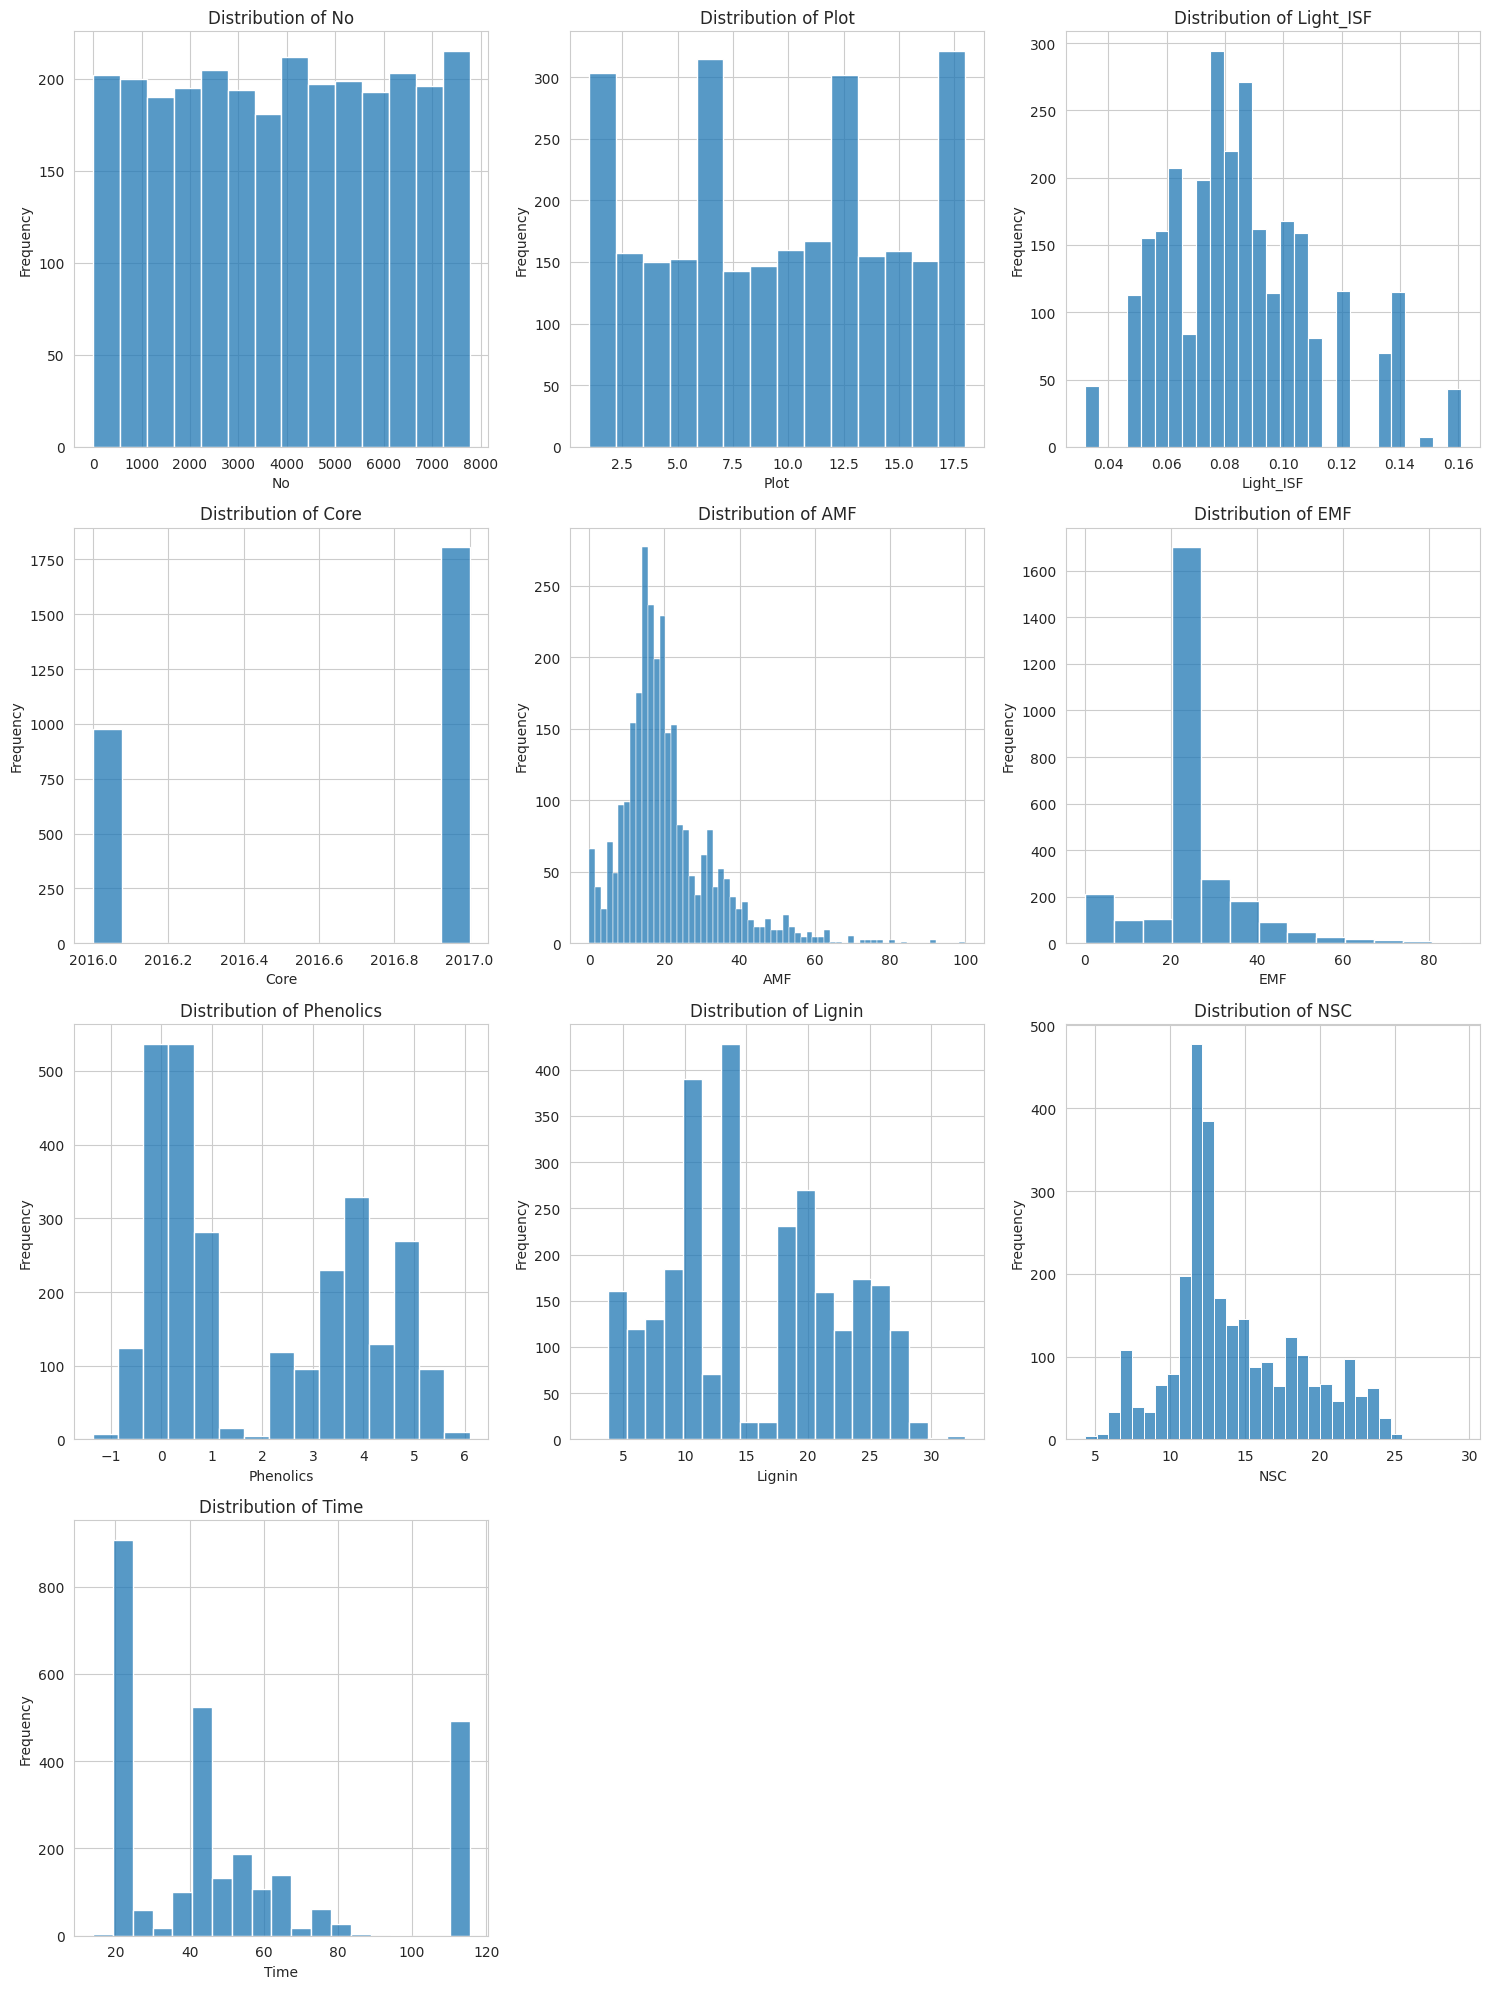

In [ ]:
import polars.selectors as cs
import math

# Set plot style
sns.set_style("whitegrid")

# Select only numerical columns for plotting
numerical_cols = df.select(cs.numeric()).columns
print("Numerical columns:", numerical_cols)

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Categorical/Boolean columns

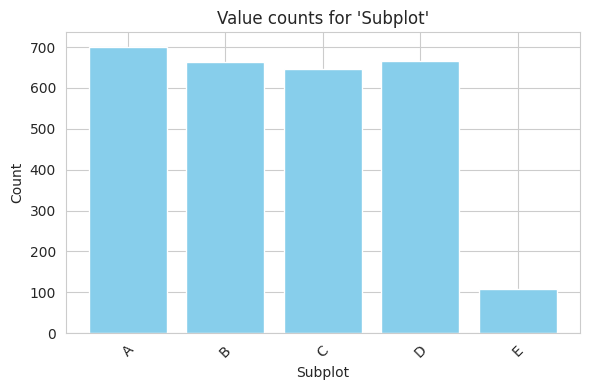

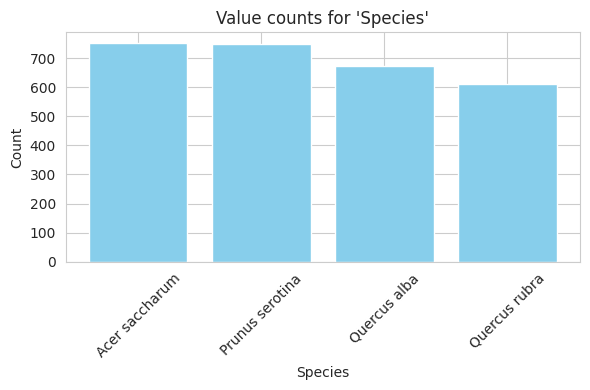

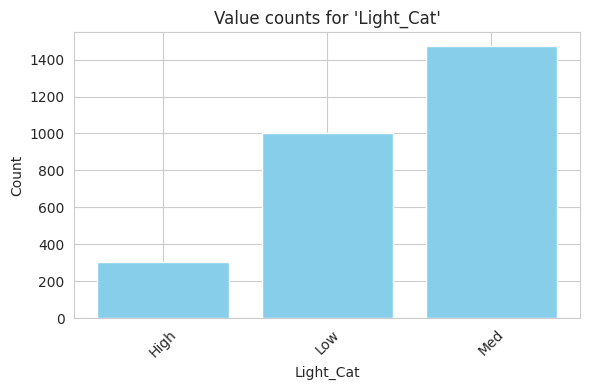

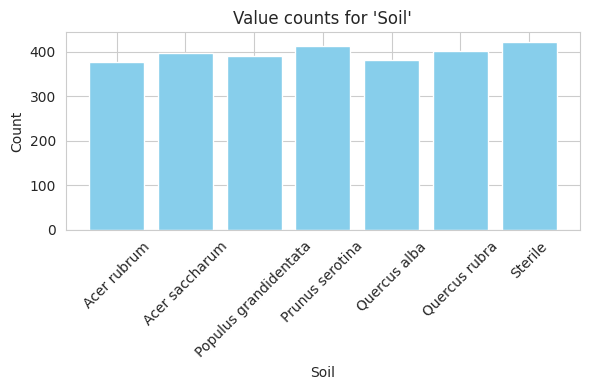

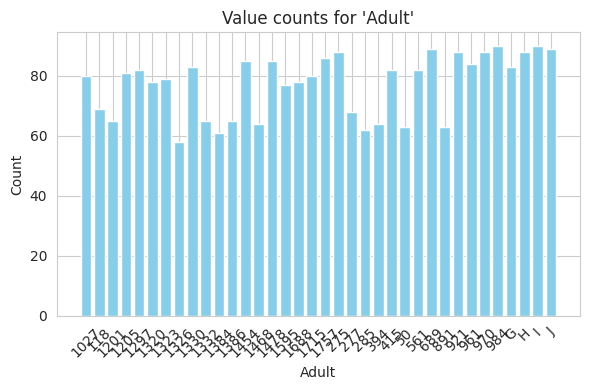

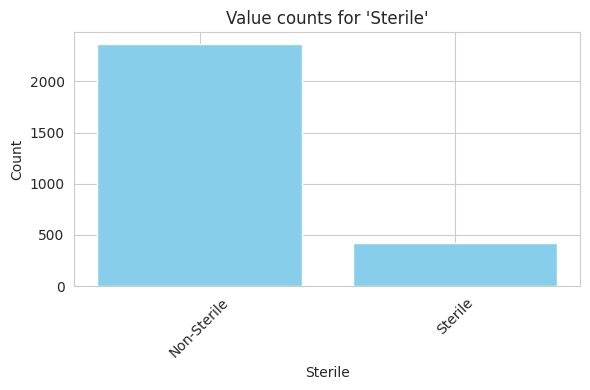

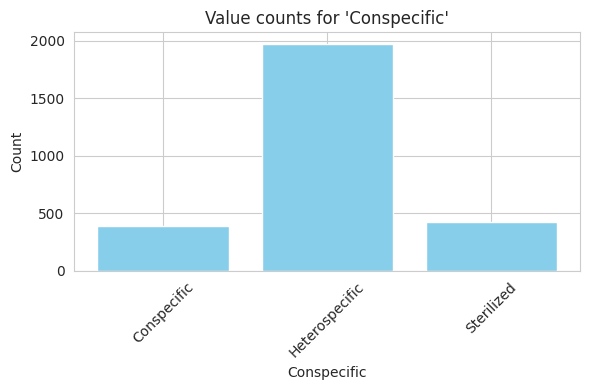

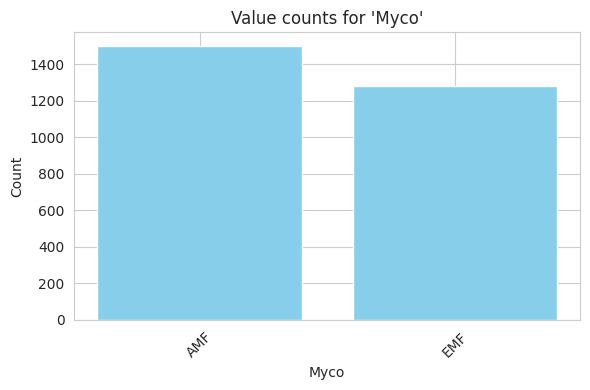

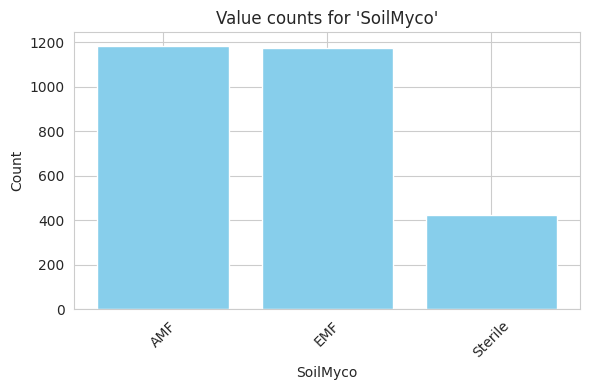

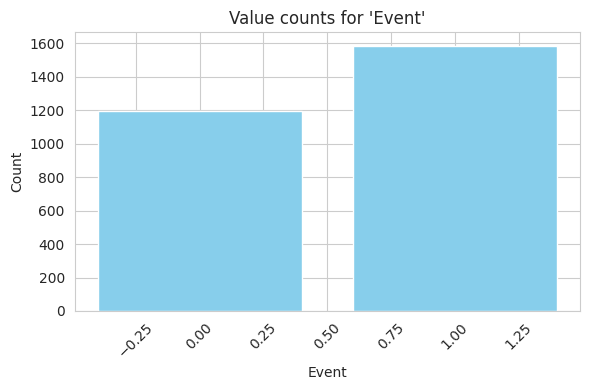

In [ ]:
# Bar plots for Cateoricals and Booleans

cat_bool_cols = df.select(cs.categorical() | cs.boolean()).columns

for col in cat_bool_cols:
    # Modern Polars: use value_counts + sort
    counts = df.select(pl.col(col).value_counts().sort()).unnest(col)

    # Extract keys and values for plotting
    keys = counts[col].to_list()
    values = counts["count"].to_list()

    # Plot
    plt.figure(figsize=(6, 4))
    plt.bar(keys, values, color="skyblue")
    plt.title(f"Value counts for '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Clarification of 'Time' and 'Event'

Based on the dataset metadata, the columns 'Time' and 'Event' are defined as follows:

*   **Time**: Represents the number of days at which the seedling died or was harvested.
*   **Event**: Used for survival analysis to indicate the status of each individual seedling at a given time.
    *   `0`: Seedling was harvested or the experiment ended (censored event).
    *   `1`: Seedling died (event of interest).

# Task
The next step is to prepare the `df_final` DataFrame for machine learning models by converting categorical features into a numerical format. This involves identifying all `object` type columns and applying one-hot encoding. This process ensures that all variables are in a suitable format for subsequent analysis and model development.

To do this, I'll first identify all columns with `object` data types. Then, I'll apply `pd.get_dummies` to these columns, creating new binary columns for each unique category. Finally, I'll concatenate these new columns with the original numerical columns and drop the original categorical columns, resulting in a fully numerical DataFrame.

## Impute Categorical Features

Convert categorical features into a numerical format using one-hot encoding.


In [ ]:
df_final = df.to_pandas()

In [ ]:
df_final.dtypes

,0
No,int32
Plot,int32
Subplot,category
Species,category
Light_ISF,float32
Light_Cat,category
Core,int32
Soil,category
Adult,category
Sterile,category


In [ ]:
categorical_cols = df_final.select_dtypes(include="category").columns.tolist()
print(f"Identified categorical columns: {categorical_cols}")

# 2. Apply one-hot encoding to these identified categorical columns.
df_encoded = pd.get_dummies(
    df_final[categorical_cols], drop_first=True
)  # drop_first to avoid multicollinearity

# 3. Concatenate the original df_final with the new dummy variables DataFrame and drop original categorical columns.
df_final = pd.concat([df_final.drop(columns=categorical_cols), df_encoded], axis=1)

print("\nDataFrame after one-hot encoding:")
print(df_final.head())
print("\nInfo of the modified DataFrame:")
df_final.info()

Identified categorical columns: ['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco']

DataFrame after one-hot encoding:
     No  Plot  Light_ISF  Core  PlantDate        AMF        EMF  Phenolics  \
0   126     1      0.106  2017 2018-06-11  22.000000  26.479843      -0.56   
1    11     1      0.106  2017 2018-05-25  15.820000  31.070000       5.19   
2    12     1      0.106  2017 2018-05-31  24.450001  28.190001       3.36   
3  2823     7      0.080  2016 2018-06-11  22.230000  26.479843      -0.71   
4  5679    14      0.060  2017 2018-06-11  21.150000  26.479843      -0.58   

   Lignin        NSC  ...  Adult_1326  Adult_H  Adult_1027  Adult_G  \
0   13.86  12.150000  ...       False    False       False    False   
1   20.52  19.290001  ...       False    False       False    False   
2   24.74  15.010000  ...       False    False       False    False   
3   14.29  12.360000  ...       False    False       False    False   
4   10.85 

In [ ]:
df_final.columns

Index(['No', 'Plot', 'Light_ISF', 'Core', 'PlantDate', 'AMF', 'EMF',
       'Phenolics', 'Lignin', 'NSC', 'Time', 'Event', 'Subplot_D', 'Subplot_A',
       'Subplot_B', 'Subplot_E', 'Species_Quercus alba',
       'Species_Quercus rubra', 'Species_Prunus serotina', 'Light_Cat_Low',
       'Light_Cat_High', 'Soil_Quercus rubra', 'Soil_Acer rubrum',
       'Soil_Populus grandidentata', 'Soil_Sterile', 'Soil_Acer saccharum',
       'Soil_Quercus alba', 'Adult_970', 'Adult_J', 'Adult_689', 'Adult_1332',
       'Adult_891', 'Adult_1595', 'Adult_1323', 'Adult_394', 'Adult_561',
       'Adult_1478', 'Adult_1320', 'Adult_1454', 'Adult_921', 'Adult_984',
       'Adult_118', 'Adult_1757', 'Adult_1384', 'Adult_1688', 'Adult_961',
       'Adult_1715', 'Adult_50', 'Adult_1468', 'Adult_1201', 'Adult_1386',
       'Adult_277', 'Adult_415', 'Adult_285', 'Adult_275', 'Adult_1205',
       'Adult_1330', 'Adult_1297', 'Adult_1326', 'Adult_H', 'Adult_1027',
       'Adult_G', 'Sterile_Sterile', 'Conspecific_

## Plot Kaplan-Meier Survival Curve

Generate and display a Kaplan-Meier survival curve using the 'Time' and 'Event' columns from the `df_final` DataFrame.


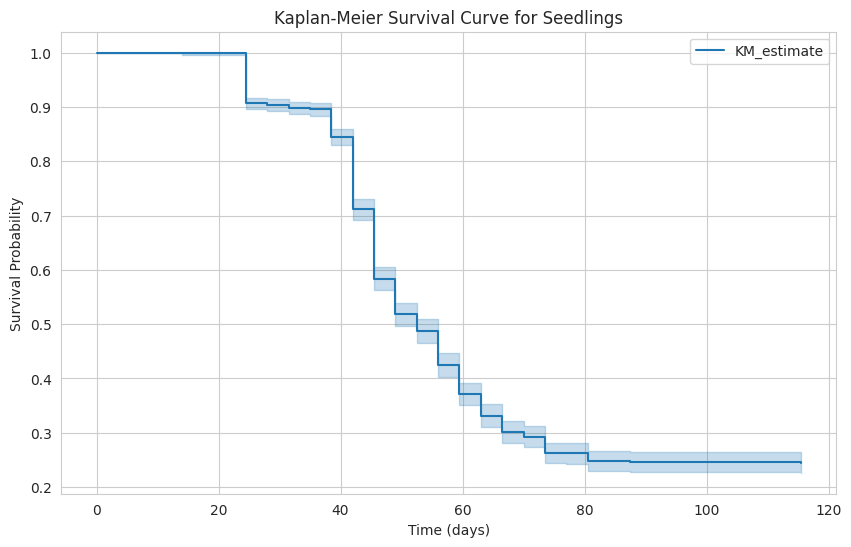

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# 'Time' is the duration, 'Event' is the event occurrence (0 for censored, 1 for event)
kmf.fit(durations=df_final["Time"], event_observed=df_final["Event"])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve for Seedlings")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# Task
Perform a log-rank test to compare the survival distributions of different groups based on 'Light_Cat' from the `Tree_Data.csv` dataset, and then fit a Cox Proportional Hazards model using the preprocessed features from the `df_final` DataFrame, including 'Time' and 'Event' columns, to assess the impact of various covariates on seedling survival time.

## Log-Rank Test

A log-rank test to compare the survival distributions of different groups based on a categorical variable (e.g., 'Light_Cat'). This will help determine if there are significant differences in survival probability between these groups.


In [22]:
from lifelines.statistics import logrank_test

df_low_light = df_final[df_final['Light_Cat_Low'] == True]
df_med_light = df_final[(df_final['Light_Cat_Low'] == False) & (df_final['Light_Cat_High'] == False)]
df_high_light = df_final[df_final['Light_Cat_High'] == True]

# Perform Log-Rank Test between 'Low' and 'Med' light categories
print("Log-Rank Test Results (Low vs. Med Light):")
results_low_med = logrank_test(durations_A=df_low_light['Time'],
                               event_observed_A=df_low_light['Event'],
                               durations_B=df_med_light['Time'],
                               event_observed_B=df_med_light['Event'])
print(f"P-value: {results_low_med.p_value:.4f}")

# Perform Log-Rank Test between 'Low' and 'High' light categories
print("\nLog-Rank Test Results (Low vs. High Light):")
results_low_high = logrank_test(durations_A=df_low_light['Time'],
                                event_observed_A=df_low_light['Event'],
                                durations_B=df_high_light['Time'],
                                event_observed_B=df_high_light['Event'])
print(f"P-value: {results_low_high.p_value:.4f}")

# Perform Log-Rank Test between 'Med' and 'High' light categories
print("\nLog-Rank Test Results (Med vs. High Light):")
results_med_high = logrank_test(durations_A=df_med_light['Time'],
                                event_observed_A=df_med_light['Event'],
                                durations_B=df_high_light['Time'],
                                event_observed_B=df_high_light['Event'])
print(f"P-value: {results_med_high.p_value:.4f}")

Log-Rank Test Results (Low vs. Med Light):
P-value: 0.1388

Log-Rank Test Results (Low vs. High Light):
P-value: 0.0640

Log-Rank Test Results (Med vs. High Light):
P-value: 0.3005


*   While the log-rank test for 'Light\_Cat' did not show significant differences, exploring other aspects of light, such as light intensity or duration, or using light as a continuous variable in the Cox model might reveal more nuanced effects.


## Training


### Train/Test data split

In [23]:
from sklearn.model_selection import train_test_split

test_size = 0.2

# change from datetime to numeric (days since earliest PlantDate)
# Otherwise the lifelines model won't work
df_final["PlantDate"] = (df_final["PlantDate"] - df_final["PlantDate"].min()).dt.days

# 8. Separate the features (all columns except 'Time' and 'Event') into a DataFrame X
# and the target variables ('Time' and 'Event') into a DataFrame y.
X = df_final.drop(columns=["Time", "Event"])
y = df_final[["Time", "Event"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2225, 66)
Shape of X_test: (557, 66)
Shape of y_train: (2225, 2)
Shape of y_test: (557, 2)


### Fit Cox Proportional Hazards Model

Fit a Cox Proportional Hazards model using the `lifelines` library on the *training* data.
This model will assess the impact of various covariates (all remaining features) on seedling survival time, incorporating elastic-net regularization to handle multicollinearity and improve model stability.

In [24]:
from lifelines import CoxPHFitter

# 2. Concatenate the training features (X_train) and training target variables (y_train) into a single DataFrame.
train_df = pd.concat([X_train, y_train], axis=1)

# 3. Instantiate a CoxPHFitter object with l1_ratio=0.1 and penalizer=0.01
cph = CoxPHFitter(l1_ratio=0.1, penalizer=0.01)

# 4. Fit the Cox Proportional Hazards model to the combined training DataFrame
cph.fit(train_df, duration_col="Time", event_col="Event")

print("Cox Proportional Hazards Model Summary:")
cph.print_summary()

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 2225 total observations, 961 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                penalizer = 0.01
                 l1 ratio = 0.1
      baseline estimation = breslow
   number of observations = 2225
number of events observed = 1264
   partial log-likelihood = -8096.28
         time fit was run = 2026-03-15 13:46:15 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
No                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Plot                        0.01      1.01      0.03           -0.05            0.07                0.95                1.07
Light_ISF                   1.41      4.09      2.59           -3.67            6.49                0.03              656.01
Core                       -0.05      0.95      0.07           -0.19            0.09                0.83                1.09
PlantDate                   0.04      1.04      0.01            0.02            0.06                1.02                1.06
AMF                         0.00      1.00      0.00           -0.01            0.01                0.99                1.01
EMF                        -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
Phenolics                  -0.21      0.81      0.08           -0.36           -0.06                0.70                0.94
Lignin                     -0.00      1.00      0.02           -0.03            0.03                0.97                1.03
NSC                        -0.00      1.00      0.02           -0.03            0.03                0.97                1.03
Subplot_D                   0.01      1.01      0.09           -0.15            0.18                0.86                1.20
Subplot_A                   0.06      1.06      0.08           -0.10            0.22                0.91                1.25
Subplot_B                  -0.04      0.96      0.09           -0.21            0.13                0.81                1.14
Subplot_E                   0.22      1.25      0.16           -0.09            0.54                0.92                1.71
Species_Quercus alba       -0.29      0.75      0.35           -0.96            0.39                0.38                1.48
Species_Quercus rubra      -0.71      0.49      0.32           -1.35           -0.08                0.26                0.93
Species_Prunus serotina    -0.02      0.98      0.13           -0.28            0.24                0.76                1.28
Light_Cat_Low               0.02      1.02      0.10           -0.19            0.22                0.83                1.25
Light_Cat_High             -0.27      0.76      0.17           -0.60            0.05                0.55                1.06
Soil_Quercus rubra         -0.26      0.77      0.27           -0.79            0.26                0.46                1.30
Soil_Acer rubrum           -0.02      0.98      0.21           -0.43            0.38                0.65                1.47
Soil_Populus grandidentata  0.10      1.11      0.17           -0.23            0.44                0.79                1.55
Soil_Sterile               -0.08      0.93      0.54           -1.13            0.98                0.32                2.67
Soil_Acer saccharum         0.29      1.34      0.17           -0.03            0.61                0.97                1.85
Soil_Quercus alba           0.05      1.05      0.28           -0.50            0.59                0.61                1.81
Adult_970                   0.69      2.00      0.29            0.13            1.26                1.14                3.51
Adult_J                     0.08      1.09      0.19           -0.28      

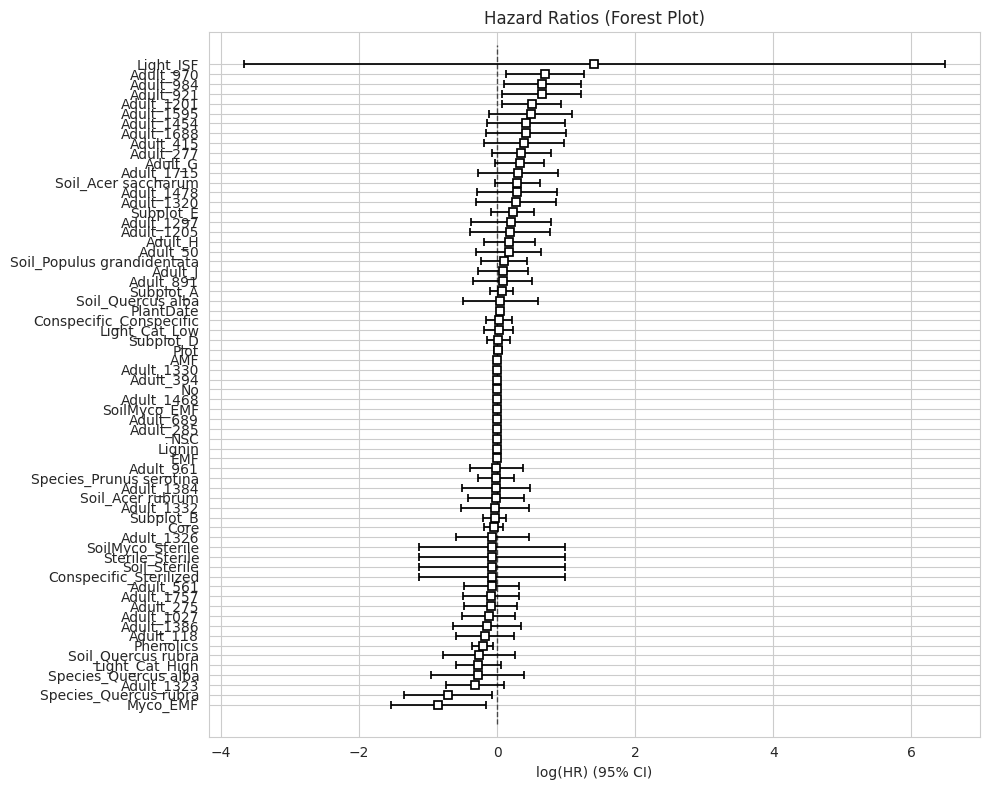

In [34]:
plt.figure(figsize=(10, 8))
cph.plot()
plt.title("Hazard Ratios (Forest Plot)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

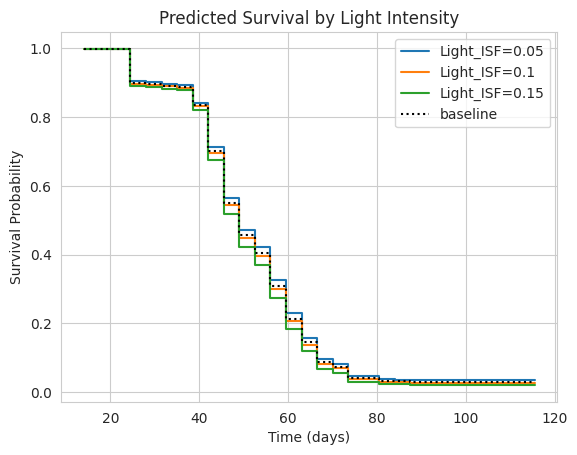

In [35]:
# Plotting the effect of different light levels on survival
plt.figure(figsize=(10, 6))
cph.plot_partial_effects_on_outcome(covariates='Light_ISF', values=[0.05, 0.10, 0.15])
plt.title("Predicted Survival by Light Intensity")
plt.ylabel("Survival Probability")
plt.xlabel("Time (days)")
plt.show()

### Evaluate Model on Test Data: C-Index and Integrated Brier Score (IBS)

In [25]:
from lifelines.utils import concordance_index

# Calculate C-Index on the training set
c_index_train = cph.score(train_df, scoring_method="concordance_index")
print(f"C-Index on training data: {c_index_train:.4f}")

test_df = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test for scoring

c_index_test = cph.score(test_df, scoring_method="concordance_index")
print(f"C-Index on test data: {c_index_test:.4f}")

C-Index on training data: 0.7768
C-Index on test data: 0.7608


## Fit Modern Model: DeepSurv (Deep Learning)


In [26]:
!pip install torchtuples pycox
import numpy as np
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sklearn.preprocessing import StandardScaler

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.9 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=684ef08a636ad0814bdb3b30c818dee35d227e2fe9a83b191a5ce25c5dab3091
  Stored in directory: /root/.cache/pip/wheels/dd/02/6b/2f0f7e1c0454094c880e63076da142e67f1ba72f82baa6195f
Successfully built feather-format


1. We fit the scaler ONLY on the training data to prevent data leakage,
then apply that same scale to the test data.

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

# 2. Format the targets for pycox
Pycox expects a tuple of (Time_Array, Event_Array) in float32 format

In [28]:
get_target = lambda df: (df['Time'].values.astype('float32'), df['Event'].values.astype('float32'))
y_train_pt = get_target(y_train)
y_test_pt = get_target(y_test)

# Validation data for monitoring training
val_data = (X_test_scaled, y_test_pt)

# 3. Define the Neural Network Architecture

In [29]:
in_features = X_train_scaled.shape[1]
num_nodes = [32, 32] # Two hidden layers
out_features = 1     # Single output node for hazard
batch_norm = True
dropout = 0.1

# Build the standard Multi-Layer Perceptron (MLP)
net = tt.practical.MLPVanilla(
    in_features,
    num_nodes,
    out_features,
    batch_norm,
    dropout
)

# 4. Initialize the DeepSurv model
Wraps the network in the CoxPH loss function

In [30]:
model = CoxPH(net, tt.optim.Adam)
model.optimizer.set_lr(0.01)

# 5. Train the model

In [31]:
epochs = 100
batch_size = 256
# EarlyStopping prevents overfitting by halting training if validation loss stalls
callbacks = [tt.callbacks.EarlyStopping()]

print("Training DeepSurv...")
log = model.fit(
    X_train_scaled,
    y_train_pt,
    batch_size,
    epochs,
    callbacks,
    val_data=val_data
)

Training DeepSurv...
0:	[1s / 1s],		train_loss: 4.5450,	val_loss: 5.0551
1:	[0s / 1s],		train_loss: 4.2843,	val_loss: 5.0202
2:	[0s / 1s],		train_loss: 4.2189,	val_loss: 5.0415
3:	[0s / 1s],		train_loss: 4.1860,	val_loss: 5.0388
4:	[0s / 1s],		train_loss: 4.1774,	val_loss: 5.0245
5:	[0s / 1s],		train_loss: 4.1381,	val_loss: 5.0520
6:	[0s / 1s],		train_loss: 4.1464,	val_loss: 5.0492
7:	[0s / 1s],		train_loss: 4.1316,	val_loss: 5.0603
8:	[0s / 1s],		train_loss: 4.1083,	val_loss: 5.0644
9:	[0s / 1s],		train_loss: 4.0942,	val_loss: 5.0627
10:	[0s / 1s],		train_loss: 4.0921,	val_loss: 5.0682
11:	[0s / 1s],		train_loss: 4.0691,	val_loss: 5.1056


# 6. Evaluate on the Test Set
Compute baseline hazards to enable actual survival predictions

In [32]:
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_scaled)

# Calculate the Concordance Index (C-Index)
ev = EvalSurv(surv, y_test_pt[0], y_test_pt[1], censor_surv='km')
c_index_deep = ev.concordance_td()

print(f"\nDeepSurv Test C-Index: {c_index_deep:.4f}")


DeepSurv Test C-Index: 0.7396


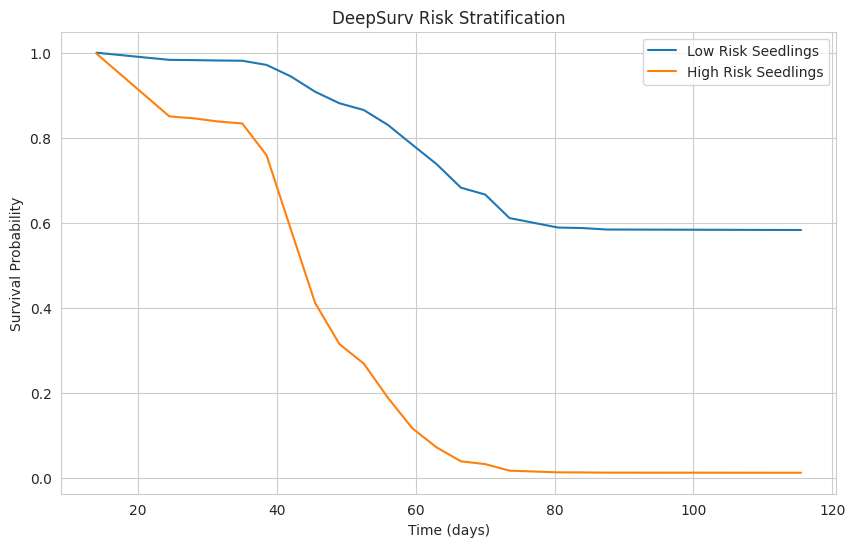

In [33]:
# 1. Predict risk scores for the test set
risk_scores = model.predict(X_test_scaled).flatten()

# 2. Divide seedlings into two groups based on the median risk score
median_risk = np.median(risk_scores)
high_risk = risk_scores > median_risk
low_risk = risk_scores <= median_risk

# 3. Plot survival curves for both groups
plt.figure(figsize=(10, 6))
surv.iloc[:, low_risk].mean(axis=1).plot(label='Low Risk Seedlings')
surv.iloc[:, high_risk].mean(axis=1).plot(label='High Risk Seedlings')

plt.title('DeepSurv Risk Stratification')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()